Learning Objectives:
- Integrate LLMs into LangGraph workflows
- Use Pydantic BaseModel for structured outputs with with_structured_output()
- Implement conditional routing based on sentiment

#### Real-World Applications:

1. Customer Service: Route tickets by urgency/sentiment with appropriate responses
2. Content Moderation: Binary classification (approved/flagged) with confidence
3. Email Response: Generate tone-appropriate replies based on sentiment strength
4. Review Analysis: Classify and respond to product reviews with matching intensity
5. Social Media Management: Brand-appropriate responses scaled to sentiment

In [6]:
from langgraph.graph import StateGraph, START, END
from  langchain_core.messages import HumanMessage, SystemMessage
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from typing import TypedDict, Literal
load_dotenv()

True

In [8]:
llm = ChatOpenAI(model="gpt-4o-mini")

In [7]:
class SentimentAnalysis(BaseModel):
    sentiment: Literal["positive", "negative"] = Field(description="The sentiment classification either positive or negative")
    confidence: float = Field(ge=0, le=1.0, description="Confidence score from 0.0 to 1.0")
    reason: str = Field(description="Brief explanation")

In [ ]:

# state definations
class SentimentState(TypedDict):
    original_tweet: str
    sentiment: str
    confidence: float
    response_tweet: str

In [9]:
# node 1
def analyze_sentiment(state: SentimentState):
    tweet = state["original_tweet"]
    messages = [
        SystemMessage("Analyze sentiment and provide the structured output. Use 0 to 1.0 scale for confidence. lower is negative and higher is positive"),
        HumanMessage(tweet)
    ]

    structured_llm = llm.with_structured_output(SentimentAnalysis)
    analysis = structured_llm.invoke(messages)
    return {'sentiment': analysis.sentiment,
            'confidence': analysis.confidence}




In [10]:
state = {'original_tweet': "Just launched my new product!"}
analyze_sentiment(state)

{'sentiment': 'positive', 'confidence': 0.9}

In [11]:
def generate_postive_response(state: SentimentState):
    
    print(f"current state in positive respone node: {state}")

    messages = [
        SystemMessage(f"""Generate a warm response to this positive tweet under 280 chars.
                      Confidence: {state['confidence']}. High confidence means be enthusiastic otherwise be friendly."""),
        HumanMessage(state['original_tweet'])
    ]

    response = llm.invoke(messages)

    return {'response_tweet': response.content.strip()}

In [12]:
def generate_negative_response(state: SentimentState):
    print(f"current state in negative respone node: {state}")

    messages = [
        SystemMessage(f"""Generate and empathetic response to this negative tweet under 280 chars.
                      If Confidence {state['confidence']} is very low then be empathetic otherwise 
                      be understanding."""),
        HumanMessage(state['original_tweet'])
    ]

    response = llm.invoke(messages)

    return {'response_tweet': response.content.strip()}


In [13]:
def route_by_sentiment(state: SentimentState):
    if state['sentiment'] == 'positive':
        return "positive_response"
    
    else:
        return "negative_response"

In [17]:
builder = StateGraph(SentimentState)
builder.add_node("analyze", analyze_sentiment)
builder.add_node("positive_response", generate_postive_response)
builder.add_node("negative_response", generate_negative_response)

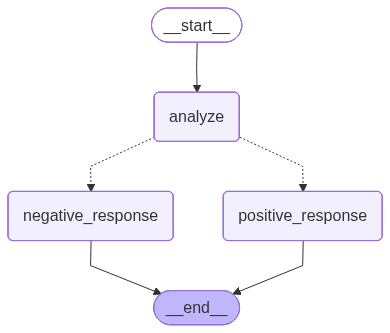

In [ ]:
# edges
builder.add_edge(START, "analyze")
builder.add_conditional_edges("analyze", route_by_sentiment, ["positive_response", "negative_response"])
builder.add_edge("positive_response", END)
builder.add_edge("negative_response", END)
graph = builder.compile()
graph

In [19]:
tweet = "Just launched my new product! the response from everyone has been amazing so far."

result = graph.invoke({'original_tweet': tweet})
result

current state in positive respone node: {'original_tweet': 'Just launched my new product! the response from everyone has been amazing so far.', 'sentiment': 'positive', 'confidence': 0.95}


{'original_tweet': 'Just launched my new product! the response from everyone has been amazing so far.',
 'sentiment': 'positive',
 'confidence': 0.95,
 'response_tweet': 'Congratulations on your launch! 🎉 It’s incredible to see your hard work paying off and receiving such positive feedback. Can’t wait to see how your product makes waves! Keep shining and inspiring others! 🚀👏 #Entrepreneurship'}